# Task 4 — Pick the Right Chart, Five Times (`mpg.csv`)

**Dataset:** 398 cars from 1970–1982.

### Lecture rules applied throughout
- The title states the finding, not just the variables.
- Bars start at zero.
- No chart uses two y-axes.
- Colour is used only when it communicates a category; otherwise it is avoided.
- Labels are selective rather than labeling every observation.
- Any excluded rows are stated on the chart.

### Missing-value decision
`horsepower` is missing for 6 cars. None of the five questions requires horsepower, so **no rows are excluded** from the analysis. The six missing horsepower values are retained in the dataset and do not affect these charts.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the supplied dataset
mpg = pd.read_csv("mpg.csv")

# Basic validation
print("Shape:", mpg.shape)
print("Missing values:")
print(mpg.isna().sum())

# The only missing field is horsepower, which is not required for Tasks 1–5.
assert mpg.shape == (398, 9)
assert mpg["horsepower"].isna().sum() == 6
assert mpg[["mpg", "model_year", "origin", "weight", "cylinders"]].isna().sum().sum() == 0

# Keep model years in chronological order and use readable origin labels.
mpg["origin_label"] = mpg["origin"].str.title()
yearly = mpg.groupby("model_year", as_index=False).agg(
    mean_mpg=("mpg", "mean"),
    mean_weight=("weight", "mean"),
    cars=("mpg", "size")
)
yearly["year"] = 1900 + yearly["model_year"]

print("\nRows used for all five charts:", len(mpg))
print("No rows excluded.")


/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-yui0x7s0 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Shape: (398, 9)
Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Rows used for all five charts: 398
No rows excluded.


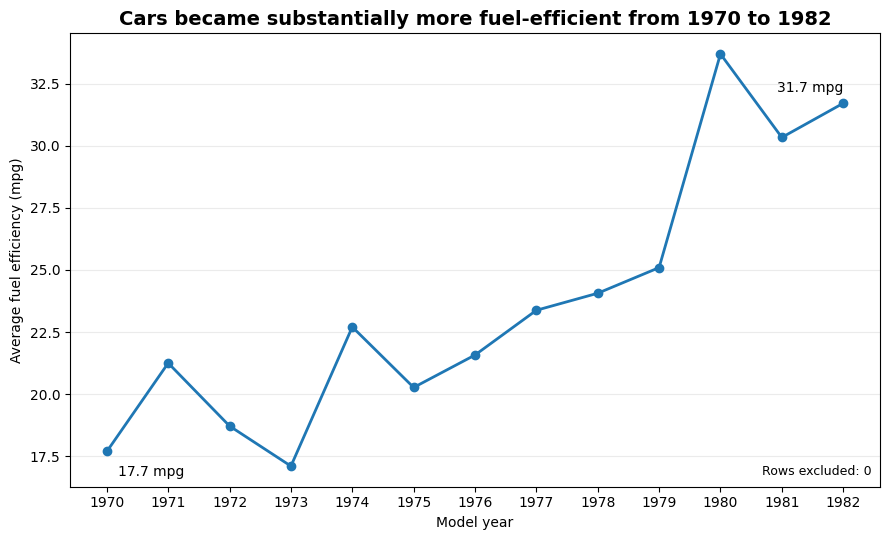

In [2]:
# 1. Did cars get more fuel-efficient between 1970 and 1982?
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(yearly["year"], yearly["mean_mpg"], marker="o", linewidth=2)
ax.set_title("Cars became substantially more fuel-efficient from 1970 to 1982", fontsize=14, weight="bold")
ax.set_xlabel("Model year")
ax.set_ylabel("Average fuel efficiency (mpg)")
ax.set_xticks(yearly["year"])
ax.grid(axis="y", alpha=0.25)

# Label only the endpoints to avoid clutter.
ax.annotate(f'{yearly["mean_mpg"].iloc[0]:.1f} mpg',
            (yearly["year"].iloc[0], yearly["mean_mpg"].iloc[0]),
            xytext=(8, -18), textcoords="offset points")
ax.annotate(f'{yearly["mean_mpg"].iloc[-1]:.1f} mpg',
            (yearly["year"].iloc[-1], yearly["mean_mpg"].iloc[-1]),
            xytext=(-48, 8), textcoords="offset points")

ax.text(0.99, 0.02, "Rows excluded: 0",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


**Why this chart type?** A **line chart** is appropriate because model year is an ordered time variable, so connecting the yearly averages makes the overall change in fuel efficiency easy to see. The average rises from about 17.7 mpg in 1970 to 31.7 mpg in 1982, although the increase is not perfectly smooth.

/tmp/ipykernel_457/835423160.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=origins, patch_artist=False, showmeans=True,


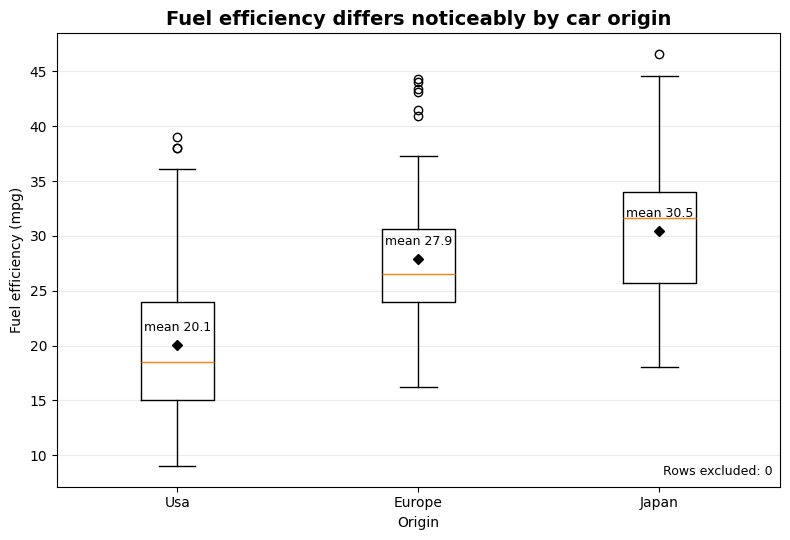

In [3]:
# 2. Do American, European and Japanese cars differ in fuel efficiency?
origins = ["Usa", "Europe", "Japan"]

fig, ax = plt.subplots(figsize=(8, 5.5))
data = [mpg.loc[mpg["origin_label"] == o, "mpg"] for o in origins]

ax.boxplot(data, labels=origins, patch_artist=False, showmeans=True,
           meanprops=dict(marker="D", markerfacecolor="black", markeredgecolor="black", markersize=5))
ax.set_title("Fuel efficiency differs noticeably by car origin", fontsize=14, weight="bold")
ax.set_xlabel("Origin")
ax.set_ylabel("Fuel efficiency (mpg)")
ax.grid(axis="y", alpha=0.25)

# Selectively label group means.
means = [x.mean() for x in data]
for i, mean in enumerate(means, start=1):
    ax.annotate(f"mean {mean:.1f}",
                (i, mean), xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9)

ax.text(0.99, 0.02, "Rows excluded: 0",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


**Why this chart type?** A **boxplot** is useful because it compares the distributions of fuel efficiency across the three origin groups, showing their centers and spread without plotting all 398 cars individually. The groups are clearly separated in their typical mpg values, with Japanese and European cars having higher typical fuel efficiency than American cars.

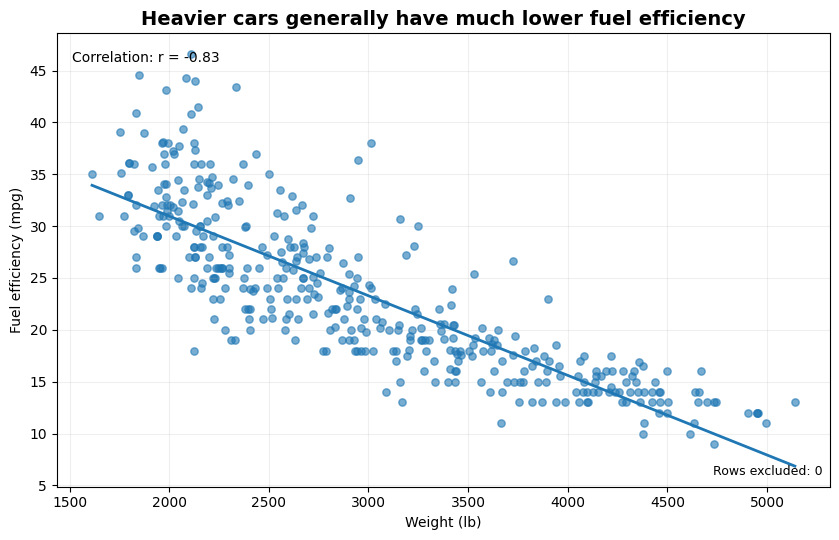

In [4]:
# 3. What is the relationship between weight and fuel efficiency?
fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.scatter(mpg["weight"], mpg["mpg"], s=28, alpha=0.6)

# Add a simple least-squares trend line.
x = mpg["weight"].to_numpy()
y = mpg["mpg"].to_numpy()
slope, intercept = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 100)
ax.plot(xx, slope * xx + intercept, linewidth=2)

r = mpg[["weight", "mpg"]].corr().iloc[0, 1]

ax.set_title("Heavier cars generally have much lower fuel efficiency", fontsize=14, weight="bold")
ax.set_xlabel("Weight (lb)")
ax.set_ylabel("Fuel efficiency (mpg)")
ax.grid(alpha=0.2)

ax.text(0.02, 0.96, f"Correlation: r = {r:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=10)
ax.text(0.99, 0.02, "Rows excluded: 0",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


**Why this chart type?** A **scatterplot** is the natural choice for two quantitative variables because it shows the direction, strength and form of their relationship rather than only group summaries. Here the strong negative association (r ≈ −0.83) shows that heavier cars generally have lower fuel efficiency, while the trend line summarizes the overall pattern without hiding the individual observations.

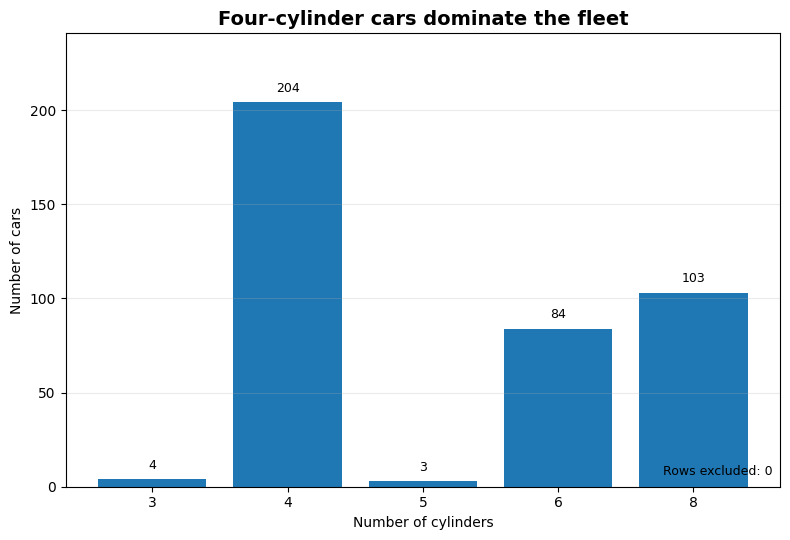

In [5]:
# 4. How is the number of cylinders distributed across the fleet?
cyl_counts = mpg["cylinders"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(cyl_counts.index.astype(str), cyl_counts.values)

ax.set_title("Four-cylinder cars dominate the fleet", fontsize=14, weight="bold")
ax.set_xlabel("Number of cylinders")
ax.set_ylabel("Number of cars")
ax.set_ylim(0, max(cyl_counts.values) * 1.18)
ax.grid(axis="y", alpha=0.25)

# Label bars because there are only five categories.
for bar, count in zip(bars, cyl_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, count + 4, str(count),
            ha="center", va="bottom", fontsize=9)

ax.text(0.99, 0.02, "Rows excluded: 0",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


**Why this chart type?** A **bar chart** is appropriate because cylinders is a discrete categorical/count variable, and the question asks how frequently each cylinder count occurs. Starting the bars at zero makes the differences in fleet counts visually honest; four-cylinder cars are by far the most common.

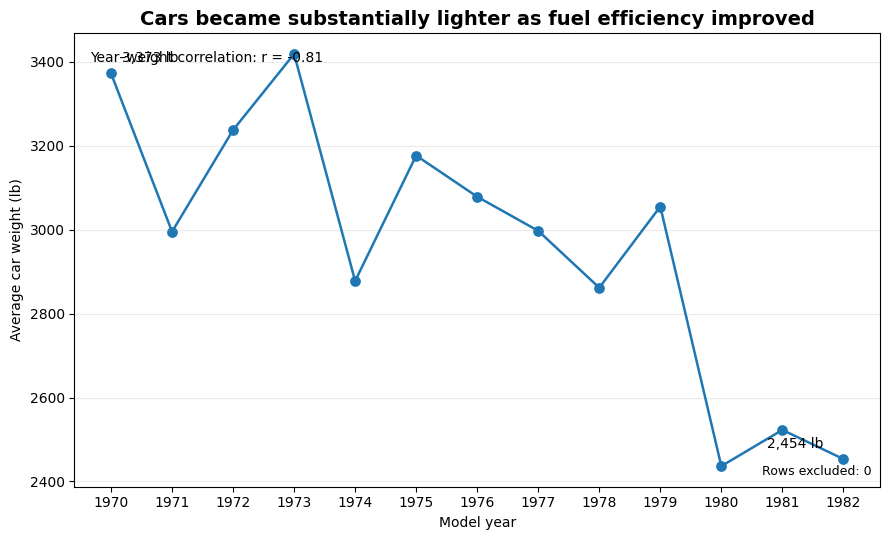

In [6]:
# 5. Is the improvement in fuel efficiency explained by cars getting lighter?
# Use annual average weight, because the question asks whether vehicle weight changed over time.
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(yearly["year"], yearly["mean_weight"], s=45)
ax.plot(yearly["year"], yearly["mean_weight"], linewidth=1.8)

weight_slope, weight_intercept = np.polyfit(yearly["year"], yearly["mean_weight"], 1)
weight_corr = yearly[["year", "mean_weight"]].corr().iloc[0, 1]

ax.set_title("Cars became substantially lighter as fuel efficiency improved", fontsize=14, weight="bold")
ax.set_xlabel("Model year")
ax.set_ylabel("Average car weight (lb)")
ax.set_xticks(yearly["year"])
ax.grid(axis="y", alpha=0.25)

ax.annotate(f'{yearly["mean_weight"].iloc[0]:,.0f} lb',
            (yearly["year"].iloc[0], yearly["mean_weight"].iloc[0]),
            xytext=(8, 8), textcoords="offset points")
ax.annotate(f'{yearly["mean_weight"].iloc[-1]:,.0f} lb',
            (yearly["year"].iloc[-1], yearly["mean_weight"].iloc[-1]),
            xytext=(-55, 8), textcoords="offset points")

ax.text(0.02, 0.96, f"Year–weight correlation: r = {weight_corr:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=10)
ax.text(0.99, 0.02, "Rows excluded: 0",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


**Why this chart type?** A **connected dot plot of yearly averages** is appropriate because the question asks whether average car weight changed across ordered model years, while keeping the number of plotted points small enough to read. Average weight fell from about 3,373 lb in 1970 to about 2,454 lb in 1982; together with the negative weight–mpg relationship in Question 3, this is consistent with lighter cars being one contributor to the fuel-efficiency improvement, but it does not by itself prove causation.

## Redrawing the weakest chart

I consider **Question 2's boxplot** the weakest of the five original charts because boxplots summarize the distributions well, but they hide much of the distribution shape and can make groups with different sample sizes look equally important.

The redraw below uses a **violin plot** instead. It keeps the comparison across origins but makes the density and shape of each mpg distribution visible. The underlying question and data stay the same; only the visual encoding changes.


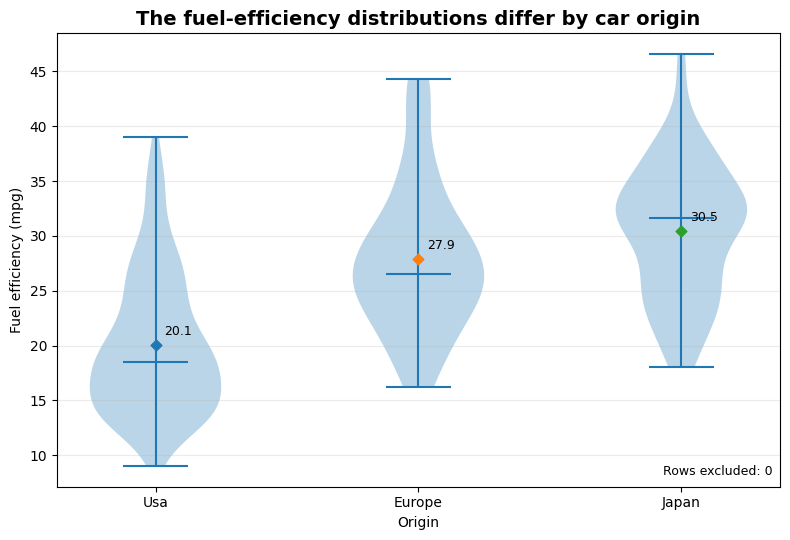

In [7]:
# Redraw of Question 2: violin plot
fig, ax = plt.subplots(figsize=(8, 5.5))

parts = ax.violinplot(data, positions=np.arange(1, len(origins) + 1),
                      showmeans=False, showmedians=True, showextrema=True)

ax.set_title("The fuel-efficiency distributions differ by car origin", fontsize=14, weight="bold")
ax.set_xlabel("Origin")
ax.set_ylabel("Fuel efficiency (mpg)")
ax.set_xticks(np.arange(1, len(origins) + 1))
ax.set_xticklabels(origins)
ax.grid(axis="y", alpha=0.25)

# Add only the group means as selective labels.
for i, mean in enumerate(means, start=1):
    ax.scatter(i, mean, marker="D", s=30, zorder=3)
    ax.annotate(f"{mean:.1f}", (i, mean), xytext=(6, 7),
                textcoords="offset points", fontsize=9)

ax.text(0.99, 0.02, "Rows excluded: 0",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


**What changed?** The original boxplot was replaced with a **violin plot** so the distribution shape within each origin is visible rather than reduced mainly to quartiles and a median. The means are still labeled selectively, so the chart remains easy to compare while showing more information about the shape of each group.

## Overall conclusion

1. **Fuel efficiency increased:** average mpg rose substantially from 1970 to 1982.
2. **Origin matters:** American, European and Japanese cars have visibly different fuel-efficiency distributions.
3. **Weight and mpg are strongly related:** heavier cars tend to have lower mpg.
4. **Four cylinders dominate:** four-cylinder cars are the largest cylinder group in this fleet.
5. **Cars also became lighter:** average weight fell substantially over the same period. Because weight is strongly associated with mpg, the data are consistent with weight reduction contributing to the improvement, but these charts alone do not establish that weight reduction caused the entire improvement.
